In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import CIFAR10
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import copy
import requests
import urllib.request
from io import BytesIO


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
IMAGE_SIZE     = 256
NUM_STEPS      = 600
CONTENT_WEIGHT = 1e3
STYLE_WEIGHT   = 1e6
LR             = 0.03


In [ ]:
def tensor_to_image(tensor):
    image = tensor.cpu().clone().squeeze(0)
    mean  = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std   = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    image = image * std + mean
    image = image.clamp(0, 1)
    return transforms.ToPILImage()(image)

def show_images(content, style, generated=None):
    n = 2 if generated is None else 3
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    axes[0].imshow(tensor_to_image(content)); axes[0].set_title("Content Image"); axes[0].axis("off")
    axes[1].imshow(tensor_to_image(style));   axes[1].set_title("Style Image");   axes[1].axis("off")
    if generated is not None:
        axes[2].imshow(tensor_to_image(generated)); axes[2].set_title("Generated Image"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

transform_content = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


Loading CIFAR-10 content image …


100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Content image label: frog, shape: torch.Size([1, 3, 256, 256])
Attempting to download style image …
✅ Style image downloaded successfully!
Style image shape: torch.Size([1, 3, 256, 256])

── Input Images ──


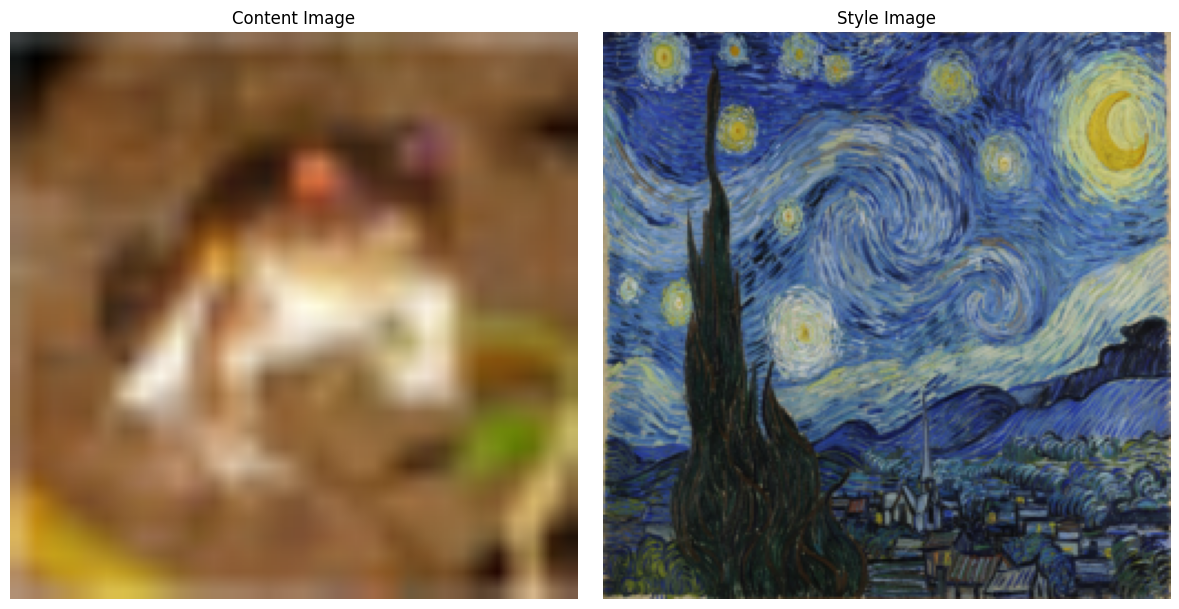

In [ ]:
# ── Load Content Image from CIFAR-10 ─────────────────────────
print("Loading CIFAR-10 content image …")
cifar       = CIFAR10(root="./data", train=True, download=True)
content_pil, label = cifar[0]
content_pil = content_pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
content_tensor = transform_content(content_pil).unsqueeze(0).to(device)
print(f"Content image label: {cifar.classes[label]}, shape: {content_tensor.shape}")

# ── Load Style Image (with urllib fix + offline fallback) ─────
def create_vangogh_style(size=IMAGE_SIZE):
    """Synthetic Van Gogh-like image using swirl + palette (offline fallback)."""
    np.random.seed(42)
    img    = np.zeros((size, size, 3), dtype=np.float32)
    colors = [
        [0.05, 0.10, 0.45],
        [0.10, 0.20, 0.60],
        [0.85, 0.80, 0.20],
        [0.95, 0.95, 0.60],
        [0.20, 0.35, 0.70],
        [0.90, 0.90, 0.90],
    ]
    for y in range(size):
        for x in range(size):
            cx, cy = x - size//2, y - size//2
            angle  = np.arctan2(cy, cx)
            dist   = np.sqrt(cx**2 + cy**2)
            swirl  = np.sin(dist * 0.05 + angle * 3 + np.sin(y * 0.02) * 3)
            wave   = np.cos(x * 0.03 + np.sin(y * 0.04) * 5)
            idx    = int((swirl + wave + 2) / 4 * (len(colors) - 1))
            idx    = np.clip(idx, 0, len(colors) - 1)
            img[y, x] = colors[idx]
    noise = np.random.normal(0, 0.04, img.shape)
    img   = np.clip(img + noise, 0, 1)
    return Image.fromarray((img * 255).astype(np.uint8))

style_pil = None
style_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"

print("Attempting to download style image …")
try:
    req = urllib.request.Request(style_url, headers={
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    })
    with urllib.request.urlopen(req, timeout=10) as resp:
        style_pil = Image.open(BytesIO(resp.read())).convert("RGB")
    print("✅ Style image downloaded successfully!")
except Exception as e:
    print(f"⚠️  Download failed ({e}). Using offline synthetic style image instead.")
    style_pil = create_vangogh_style(IMAGE_SIZE)

style_pil    = style_pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
style_tensor = transform_content(style_pil).unsqueeze(0).to(device)
print(f"Style image shape: {style_tensor.shape}")

print("\n── Input Images ──")
show_images(content_tensor, style_tensor)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2. PRETRAINED VGG19 (freeze all weights)
# ═══════════════════════════════════════════════════════════════

vgg19 = models.vgg19(pretrained=True).features.to(device).eval()
for param in vgg19.parameters():
    param.requires_grad_(False)

print("\nVGG19 loaded and frozen ✅")

LAYER_MAP = {
    '0' :'conv1_1', '1' :'relu1_1', '2' :'conv1_2', '3' :'relu1_2', '4' :'pool1',
    '5' :'conv2_1', '6' :'relu2_1', '7' :'conv2_2', '8' :'relu2_2', '9' :'pool2',
    '10':'conv3_1','11':'relu3_1','12':'conv3_2','13':'relu3_2',
    '14':'conv3_3','15':'relu3_3','16':'conv3_4','17':'relu3_4','18':'pool3',
    '19':'conv4_1','20':'relu4_1','21':'conv4_2','22':'relu4_2',
    '23':'conv4_3','24':'relu4_3','25':'conv4_4','26':'relu4_4','27':'pool4',
    '28':'conv5_1','29':'relu5_1','30':'conv5_2','31':'relu5_2',
    '32':'conv5_3','33':'relu5_3','34':'conv5_4','35':'relu5_4','36':'pool5',
}

CONTENT_LAYERS = ['conv4_2']
STYLE_LAYERS   = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 100MB/s] 



VGG19 loaded and frozen ✅


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3. FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════

def get_features(image, model, layer_map=LAYER_MAP):
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        layer_name = layer_map.get(name)
        if layer_name in (CONTENT_LAYERS + STYLE_LAYERS):
            features[layer_name] = x
    return features


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 4. LOSS FUNCTIONS
# ═══════════════════════════════════════════════════════════════

def content_loss(generated_feat, content_feat):
    return torch.mean((generated_feat - content_feat) ** 2)

def gram_matrix(tensor):
    _, C, H, W = tensor.size()
    features   = tensor.view(C, H * W)
    G          = torch.mm(features, features.t())
    return G / (C * H * W)

def style_loss(generated_feats, style_feats):
    loss = 0.0
    for layer in STYLE_LAYERS:
        G_gen   = gram_matrix(generated_feats[layer])
        G_style = gram_matrix(style_feats[layer])
        loss   += torch.mean((G_gen - G_style) ** 2)
    return loss / len(STYLE_LAYERS)

def total_loss(gen_feats, content_feats, style_feats,
               alpha=CONTENT_WEIGHT, beta=STYLE_WEIGHT):
    c_loss = sum(content_loss(gen_feats[l], content_feats[l])
                 for l in CONTENT_LAYERS)
    s_loss = style_loss(gen_feats, style_feats)
    return alpha * c_loss + beta * s_loss, c_loss, s_loss


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 5. IMAGE OPTIMIZATION
# ═══════════════════════════════════════════════════════════════

content_features = get_features(content_tensor, vgg19)
style_features   = get_features(style_tensor,   vgg19)

generated  = content_tensor.clone().requires_grad_(True).to(device)
optimizer  = optim.Adam([generated], lr=LR)

print(f"\nStarting optimization for {NUM_STEPS} steps …")
print(f"Content weight (α): {CONTENT_WEIGHT:.0e}")
print(f"Style weight   (β): {STYLE_WEIGHT:.0e}\n")

history = {"total": [], "content": [], "style": []}

for step in range(1, NUM_STEPS + 1):
    with torch.no_grad():
        generated.clamp_(
            min=torch.tensor([-2.1179, -2.0357, -1.8044]).to(device).view(1,3,1,1),
            max=torch.tensor([ 2.2489,  2.4286,  2.6400]).to(device).view(1,3,1,1)
        )

    optimizer.zero_grad()
    gen_feats = get_features(generated, vgg19)
    t_loss, c_loss, s_loss = total_loss(gen_feats, content_features, style_features)
    t_loss.backward()
    optimizer.step()

    history["total"].append(t_loss.item())
    history["content"].append(c_loss.item())
    history["style"].append(s_loss.item())

    if step % 50 == 0 or step == 1:
        print(f"Step [{step:>3}/{NUM_STEPS}]  "
              f"Total: {t_loss.item():.4f}  "
              f"Content: {c_loss.item():.4f}  "
              f"Style: {s_loss.item():.6f}")


Starting optimization for 600 steps …
Content weight (α): 1e+03
Style weight   (β): 1e+06

Step [  1/600]  Total: 54.8108  Content: 0.0000  Style: 0.000055
Step [ 50/600]  Total: 126.3103  Content: 0.0838  Style: 0.000043
Step [100/600]  Total: 86.0555  Content: 0.0451  Style: 0.000041
Step [150/600]  Total: 73.8147  Content: 0.0336  Style: 0.000040
Step [200/600]  Total: 67.8806  Content: 0.0283  Style: 0.000040
Step [250/600]  Total: 64.4210  Content: 0.0254  Style: 0.000039
Step [300/600]  Total: 61.5211  Content: 0.0230  Style: 0.000039
Step [350/600]  Total: 60.2045  Content: 0.0221  Style: 0.000038
Step [400/600]  Total: 57.8745  Content: 0.0201  Style: 0.000038
Step [450/600]  Total: 57.5850  Content: 0.0202  Style: 0.000037
Step [500/600]  Total: 56.8220  Content: 0.0198  Style: 0.000037
Step [550/600]  Total: 55.0824  Content: 0.0184  Style: 0.000037
Step [600/600]  Total: 55.5677  Content: 0.0191  Style: 0.000036



── Final Output ──


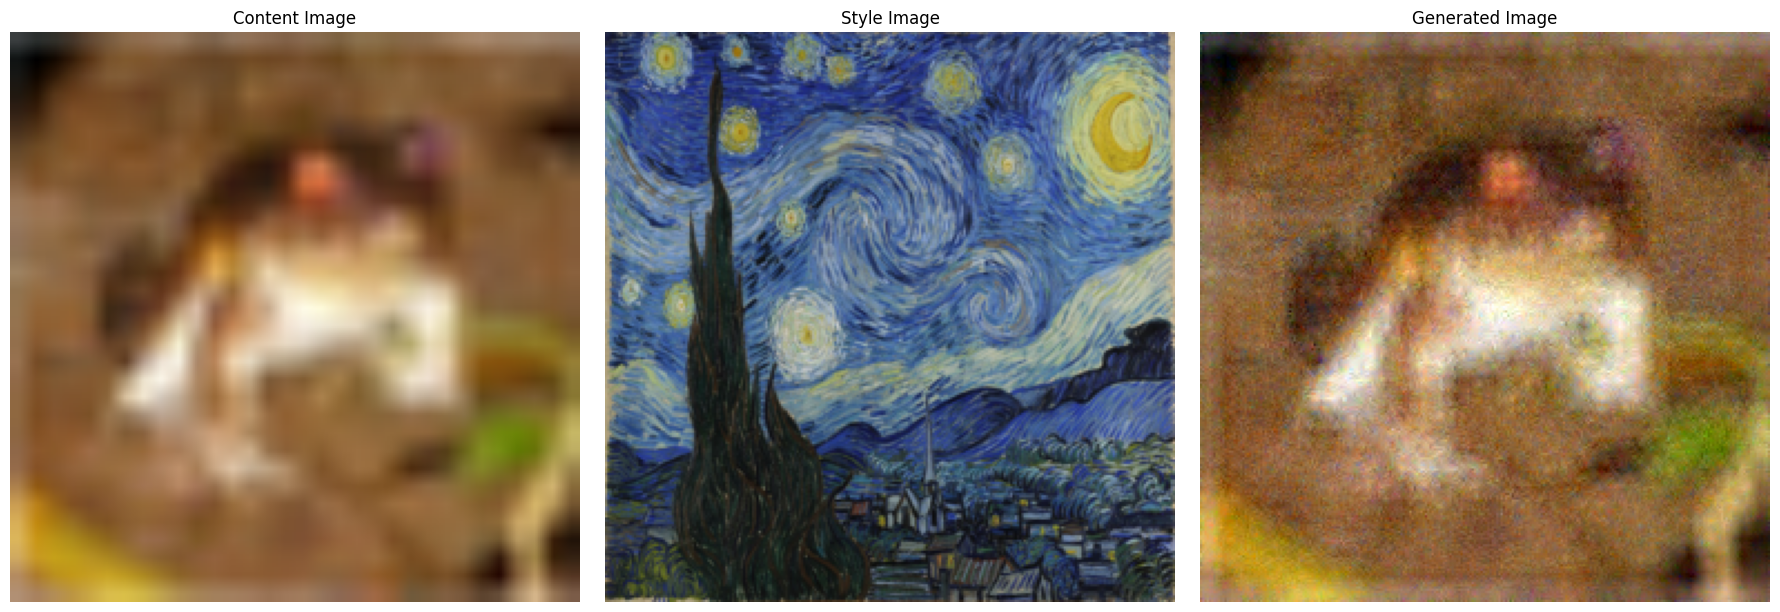

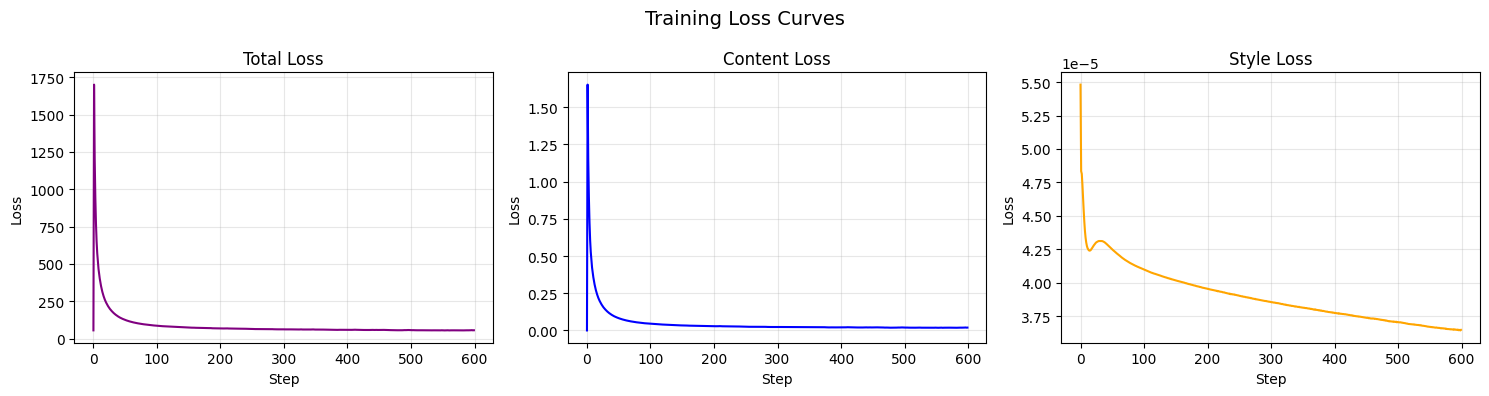


✅ Stylized image saved as 'nst_output.jpg'

╔══════════════════════════════════════════════════════╗
║          Neural Style Transfer – Summary             ║
╠══════════════════════════════════════════════════════╣
║  Backbone     : VGG19 (pretrained, frozen)           ║
║  Content layer: conv4_2  (high-level structure)      ║
║  Style layers : conv1_1 → conv5_1  (multi-scale)     ║
║  Loss         : α·L_content + β·L_style              ║
║  Optimizer    : Adam                                 ║
╚══════════════════════════════════════════════════════╝



In [ ]:
# ═══════════════════════════════════════════════════════════════
# 6. RESULTS
# ═══════════════════════════════════════════════════════════════

print("\n── Final Output ──")
show_images(content_tensor, style_tensor, generated.detach())

# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, color in zip(axes, ["total","content","style"], ["purple","blue","orange"]):
    ax.plot(history[key], color=color)
    ax.set_title(f"{key.capitalize()} Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
plt.suptitle("Training Loss Curves", fontsize=14)
plt.tight_layout()
plt.show()

# Save output
output_img = tensor_to_image(generated.detach())
output_img.save("nst_output.jpg")
print("\n✅ Stylized image saved as 'nst_output.jpg'")

print("""
╔══════════════════════════════════════════════════════╗
║          Neural Style Transfer – Summary             ║
╠══════════════════════════════════════════════════════╣
║  Backbone     : VGG19 (pretrained, frozen)           ║
║  Content layer: conv4_2  (high-level structure)      ║
║  Style layers : conv1_1 → conv5_1  (multi-scale)     ║
║  Loss         : α·L_content + β·L_style              ║
║  Optimizer    : Adam                                 ║
╚══════════════════════════════════════════════════════╝
""")
